In [2]:
import albumentations
from pathlib import Path
import cv2
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import tqdm

In [3]:
INPUT_PATH_SMALL = Path("/home/samuel/test/MasterThesis/Orthomosaics/small/original/processed_output/image_tiles")
INPUT_PATH_MID  = Path("/home/samuel/test/MasterThesis/Orthomosaics/mid/original/processed_output/image_tiles")
INPUT_PATH_LARGE = Path("/home/samuel/test/MasterThesis/Orthomosaics/large/original/processed_output/image_tiles")

INPUT_PATH_LABELS_SMALL = Path("/home/samuel/test/MasterThesis/Orthomosaics/small/original/labels")
INPUT_PATH_LABELS_MID  = Path("/home/samuel/test/MasterThesis/Orthomosaics/mid/original/labels")
INPUT_PATH_LABELS_LARGE = Path("/home/samuel/test/MasterThesis/Orthomosaics/large/original/labels")


OUTPUT_PATH_SMALL = Path("/home/samuel/test/MasterThesis/Orthomosaics/small/augmented")
OUTPUT_PATH_MID = Path("/home/samuel/test/MasterThesis/Orthomosaics/mid/augmented")
OUTPUT_PATH_LARGE = Path("/home/samuel/test/MasterThesis/Orthomosaics/large/augmented")

INPUT_PATHS = [INPUT_PATH_SMALL, INPUT_PATH_MID, INPUT_PATH_LARGE]
INPUT_LABEL_PATHS = [INPUT_PATH_LABELS_SMALL, INPUT_PATH_LABELS_MID, INPUT_PATH_LABELS_LARGE]
OUTPUT_PATHS = [OUTPUT_PATH_SMALL, OUTPUT_PATH_MID, OUTPUT_PATH_LARGE]

Image shape: (1, 1024, 1024)


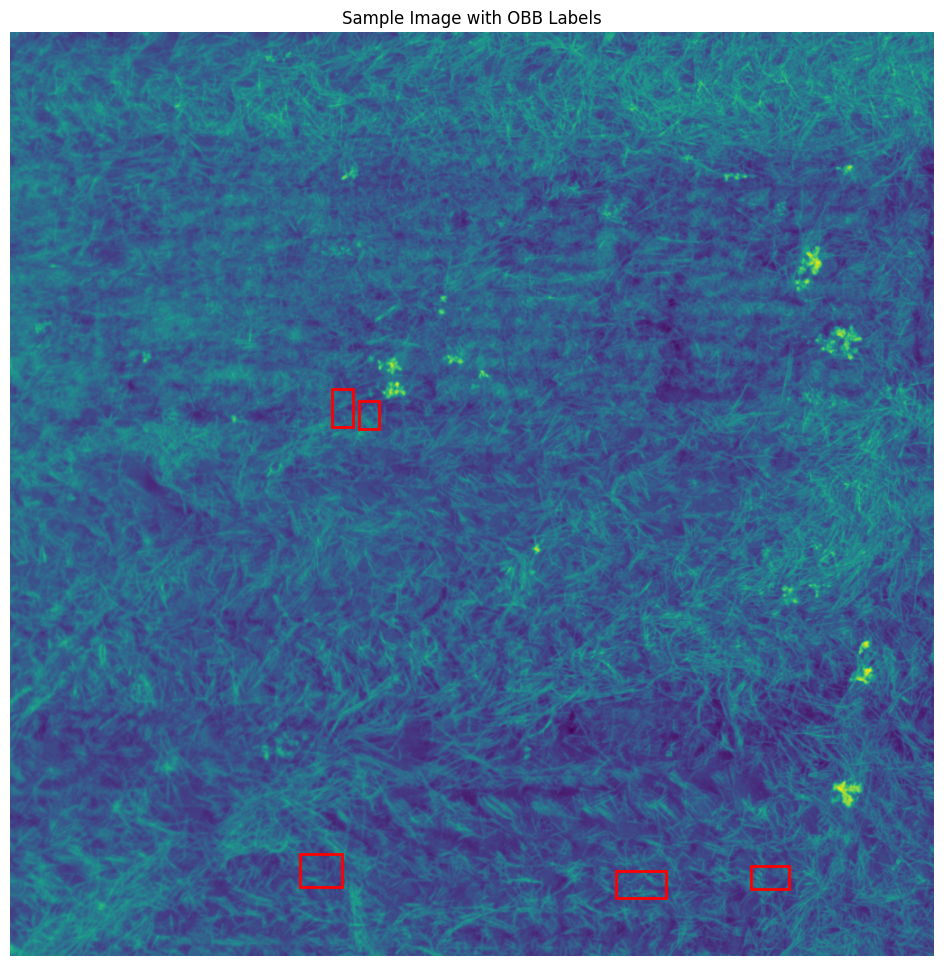

In [9]:
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt
import numpy as np
import cv2
import rasterio

labels = []
with rasterio.open("/home/samuel/test/MasterThesis/Orthomosaics/large/augmented/horizontal/processed_images/image_tiles/Bjornkjaervej_TestFlight_2_bigger_tile_1_6.tif") as src:
    img = src.read([7])  # (C, H, W)
    profile = src.profile
    print("Image shape:", img.shape)
    img = np.transpose(img)
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    w = img.shape[1]
    h = img.shape[0]

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(img)
    ax.set_title("Sample Image with OBB Labels")
    ax.axis("off")

    # Read and plot all labels
    with open("/home/samuel/test/MasterThesis/Orthomosaics/large/augmented/horizontal/labels/Bjornkjaervej_TestFlight_2_bigger_tile_1_6.txt", "r") as f:
        for line in f:
            parts = line.strip().split()
            x_1, y_1, x_2, y_2, x_3, y_3, x_4, y_4 = map(float, parts[1:9])
            labels.append([x_1 , y_1, x_2, y_2, x_3, y_3, x_4, y_4])
            
            # Convert normalized → pixel coordinates
            pts = np.array([
                [x_1 * w, y_1 * h],
                [x_2 * w, y_2 * h],
                [x_3 * w, y_3 * h],
                [x_4 * w, y_4 * h]
            ])
            
            # Create polygon patch and add to axis
            poly = Polygon(pts, closed=True, fill=False, 
                          edgecolor='red', linewidth=2)
            ax.add_patch(poly)

    plt.show()

In [ ]:
import os
import tqdm
import numpy as np

def flip_multiband(img, flip_type):
    """
    img: (C, H, W) array
    flip_type: 'horizontal', 'vertical', or 'both'
    """
    if flip_type == 'horizontal':
        return img[:, :, ::-1]  # Flip along width axis
    elif flip_type == 'vertical':
        return img[:, ::-1, :]  # Flip along height axis
    elif flip_type == 'both':
        return img[:, ::-1, ::-1]  # Flip both
    return img


def transform_obb_coords(coords, transform_type):
    """
    Transform OBB coordinates for flips.
    coords: list of [x1, y1, x2, y2, x3, y3, x4, y4] in normalized [0,1]
    """
    pts = np.array(coords).reshape(4, 2)
    
    if transform_type == 'horizontal':
        pts[:, 0] = 1.0 - pts[:, 0]  # Flip x
    elif transform_type == 'vertical':
        pts[:, 1] = 1.0 - pts[:, 1]  # Flip y
    elif transform_type == 'both':
        pts[:, 0] = 1.0 - pts[:, 0]  # Flip x
        pts[:, 1] = 1.0 - pts[:, 1]  # Flip y
    
    return pts.flatten().tolist()


In [6]:
for image_path, label_path, output_path in zip(sorted(INPUT_PATHS), sorted(INPUT_LABEL_PATHS), sorted(OUTPUT_PATHS)):
    print(f"Processing {image_path} with labels from {label_path} → output to {output_path}")

    images = sorted(os.listdir(image_path))
    labels = sorted(os.listdir(label_path))

    output_horizontal_label_path = output_path / "horizontal/labels"
    output_horizontal_image_path = output_path / "horizontal/processed_images/image_tiles"

    os.makedirs(output_horizontal_label_path, exist_ok=True)
    os.makedirs(output_horizontal_image_path, exist_ok=True)

    output_vertical_label_path = output_path / "vertical/labels"
    output_vertical_image_path = output_path / "vertical/processed_images/image_tiles"

    os.makedirs(output_vertical_label_path, exist_ok=True)
    os.makedirs(output_vertical_image_path, exist_ok=True)

    output_horizontal_vertical_label_path = output_path / "horizontal_vertical/labels"
    output_horizontal_vertical_image_path = output_path / "horizontal_vertical/processed_images/image_tiles"

    os.makedirs(output_horizontal_vertical_label_path, exist_ok=True)
    os.makedirs(output_horizontal_vertical_image_path, exist_ok=True)


    for image_file, label_file in tqdm.tqdm(zip(images, labels), total=len(images), desc=f"Processing {image_path.name}"):

        with rasterio.open(image_path / image_file) as src:
            img = src.read()  # (C, H, W)

            transformed_img = flip_multiband(img, 'horizontal')
            # Save transformed image
            output_image_file = output_horizontal_image_path / image_file
            with rasterio.open(output_image_file, 'w', **src.profile) as dst:
                dst.write(transformed_img)


            transformed_img = flip_multiband(img, 'vertical')
            # Save transformed image
            output_image_file = output_vertical_image_path / image_file
            with rasterio.open(output_image_file, 'w', **src.profile) as dst:
                dst.write(transformed_img)
        
            transformed_img = flip_multiband(img, 'both')
            # Save transformed image
            output_image_file = output_horizontal_vertical_image_path / image_file
            with rasterio.open(output_image_file, 'w', **src.profile) as dst:
                dst.write(transformed_img)
            
        # Read labels
        with open(label_path / label_file, "r") as f:
            labels = []
            for line in f:
                parts = line.strip().split()
                x_1, y_1, x_2, y_2, x_3, y_3, x_4, y_4 = map(float, parts[1:9])
                labels.append([x_1, y_1, x_2, y_2, x_3, y_3, x_4, y_4])
            # Save horizontal flip labels
            transformed_labels = [transform_obb_coords(label, 'horizontal') for label in labels]
            output_label_file = output_horizontal_label_path / label_file
            with open(output_label_file, "w") as f1:
                for label in transformed_labels:
                    f1.write(f"0 {' '.join(map(str, label))}\n")
            f1.close()

            # Save vertical flip labels
            transformed_labels = [transform_obb_coords(label, 'vertical') for label in labels]
            output_label_file = output_vertical_label_path / label_file
            with open(output_label_file, "w") as f2:
                for label in transformed_labels:
                    f2.write(f"0 {' '.join(map(str, label))}\n") 
            f2.close()

            # Save horizontal + vertical flip labels
            transformed_labels = [transform_obb_coords(label, 'both') for label in labels]
            output_label_file = output_horizontal_vertical_label_path / label_file
            with open(output_label_file, "w") as f3:
                for label in transformed_labels:
                    f3.write(f"0 {' '.join(map(str, label))}\n")
            f3.close()
        f.close()

Processing /home/samuel/test/MasterThesis/Orthomosaics/large/original/processed_output/image_tiles with labels from /home/samuel/test/MasterThesis/Orthomosaics/large/original/labels → output to /home/samuel/test/MasterThesis/Orthomosaics/large/augmented


Processing image_tiles: 100%|██████████| 469/469 [18:10<00:00,  2.33s/it]


Processing /home/samuel/test/MasterThesis/Orthomosaics/mid/original/processed_output/image_tiles with labels from /home/samuel/test/MasterThesis/Orthomosaics/mid/original/labels → output to /home/samuel/test/MasterThesis/Orthomosaics/mid/augmented


Processing image_tiles: 100%|██████████| 246/246 [03:21<00:00,  1.22it/s]


Processing /home/samuel/test/MasterThesis/Orthomosaics/small/original/processed_output/image_tiles with labels from /home/samuel/test/MasterThesis/Orthomosaics/small/original/labels → output to /home/samuel/test/MasterThesis/Orthomosaics/small/augmented


Processing image_tiles:  99%|█████████▊| 144/146 [04:08<00:03,  1.72s/it]
